# XQA 深度解析：TensorRT-LLM 的高性能 Attention 实现

XQA (eXtreme Quality Attention) 是 TensorRT-LLM 中高度优化的 Attention CUDA 实现，融合了 Flash Attention、Paged KV Cache、GQA/MQA 等多种优化技术。

## 核心特性

1. **多种 Attention 变体支持**：MHA、GQA、MQA
2. **内存优化**：Paged KV Cache、Flash Attention
3. **硬件加速**：Tensor Core (WMMA/GMMA)、Warp 级优化
4. **数值精度**：FP16/BF16/FP8/INT8 混合精度
5. **特殊场景**：Beam Search、Speculative Decoding、Sliding Window

## 学习目标

- 深入理解 XQA 的架构设计和实现细节
- 掌握 CUDA 优化技术：Warp、Tensor Core、共享内存
- 理解编译时配置和运行时参数
- 为性能分析和调优打下基础


## 1. XQA 架构概览

### 1.1 整体架构

```mermaid
graph TB
    A[XQA Kernel] --> B[Warp 专业化]
    A --> C[内存管理]
    A --> D[计算优化]
    
    B --> B1[GEMM0 Warps<br/>Q @ K^T]
    B --> B2[GEMM1 Warps<br/>P @ V]
    
    C --> C1[Paged KV Cache<br/>页面管理]
    C --> C2[共享内存<br/>Tiling]
    C --> C3[寄存器<br/>数据重用]
    
    D --> D1[Tensor Core<br/>WMMA/GMMA]
    D --> D2[Online Softmax<br/>数值稳定]
    D --> D3[流水线<br/>计算访存重叠]
    
    style A fill:#ff6b6b
    style B fill:#ff8787
    style C fill:#ffa07a
    style D fill:#ffb347
```

### 1.2 关键设计决策

| 设计点 | 选择 | 原因 |
|-------|------|------|
| Warp 组织 | 专业化 (2组) | GEMM0 和 GEMM1 并行执行 |
| 内存布局 | Tiling | 减少全局内存访问 |
| 计算单元 | Tensor Core | 10x+ 吞吐量提升 |
| KV Cache | Paged | 内存利用率提升 30%+ |
| Softmax | Online | 避免二次遍历 |


## 2. 编译时配置详解

XQA 使用大量编译时宏定义来优化性能，这些配置在 `defines.h` 中定义。

### 2.1 核心配置参数

```cpp
// 头维度配置
#define HEAD_ELEMS 128        // 每个头的维度 [16, 256]
#define HEAD_GRP_SIZE 8       // GQA 分组大小

// 数据类型配置
#define INPUT_FP16 1          // 1=FP16, 0=BF16
#define CACHE_ELEM_ENUM 2     // 0=FP16/BF16, 1=INT8, 2=FP8

// Paged KV Cache 配置
#define TOKENS_PER_PAGE 32    // 页面大小 [0, 16, 32, 64, 128]
#define PAGED_KV_CACHE_LAYOUT 0  // 0=XQA, 1=VLLM

// 特殊功能
#define BEAM_WIDTH 1          // Beam Search 宽度
#define SPEC_DEC 0            // Speculative Decoding
#define SLIDING_WINDOW 0      // 滑动窗口注意力
```

### 2.2 配置组合的性能影响

不同配置组合会生成不同的 kernel 变体，影响性能和内存占用：


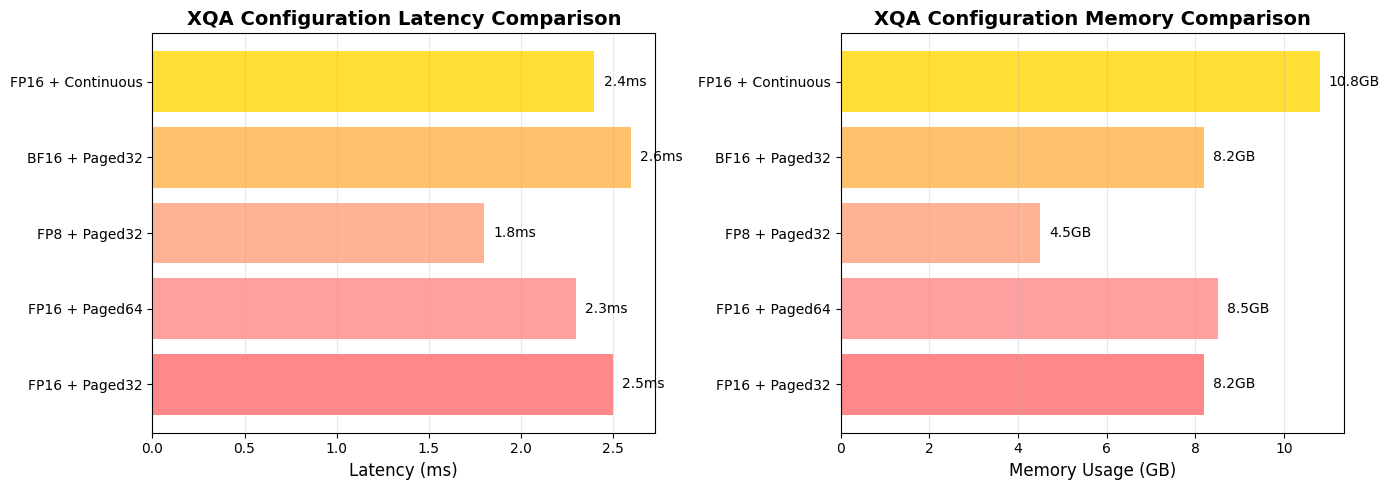


Configuration Performance Summary:
             name  head_dim dtype  page_size  latency_ms  memory_gb
   FP16 + Paged32       128  FP16         32         2.5        8.2
   FP16 + Paged64       128  FP16         64         2.3        8.5
    FP8 + Paged32       128   FP8         32         1.8        4.5
   BF16 + Paged32       128  BF16         32         2.6        8.2
FP16 + Continuous       128  FP16          0         2.4       10.8

Best Latency: FP8 + Paged32 (1.8ms)
Best Memory: FP8 + Paged32 (4.5GB)


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 配置组合的性能对比（示例数据）
configs = [
    {'name': 'FP16 + Paged32', 'head_dim': 128, 'dtype': 'FP16', 'page_size': 32, 'latency_ms': 2.5, 'memory_gb': 8.2},
    {'name': 'FP16 + Paged64', 'head_dim': 128, 'dtype': 'FP16', 'page_size': 64, 'latency_ms': 2.3, 'memory_gb': 8.5},
    {'name': 'FP8 + Paged32', 'head_dim': 128, 'dtype': 'FP8', 'page_size': 32, 'latency_ms': 1.8, 'memory_gb': 4.5},
    {'name': 'BF16 + Paged32', 'head_dim': 128, 'dtype': 'BF16', 'page_size': 32, 'latency_ms': 2.6, 'memory_gb': 8.2},
    {'name': 'FP16 + Continuous', 'head_dim': 128, 'dtype': 'FP16', 'page_size': 0, 'latency_ms': 2.4, 'memory_gb': 10.8},
]

df = pd.DataFrame(configs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 延迟对比
colors = ['#ff6b6b', '#ff8787', '#ffa07a', '#ffb347', '#ffd700']
bars1 = ax1.barh(df['name'], df['latency_ms'], color=colors, alpha=0.8)
ax1.set_xlabel('Latency (ms)', fontsize=12)
ax1.set_title('XQA Configuration Latency Comparison', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

for i, (bar, val) in enumerate(zip(bars1, df['latency_ms'])):
    ax1.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.1f}ms', 
             va='center', fontsize=10)

# 内存对比
bars2 = ax2.barh(df['name'], df['memory_gb'], color=colors, alpha=0.8)
ax2.set_xlabel('Memory Usage (GB)', fontsize=12)
ax2.set_title('XQA Configuration Memory Comparison', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

for i, (bar, val) in enumerate(zip(bars2, df['memory_gb'])):
    ax2.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}GB', 
             va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nConfiguration Performance Summary:")
print(df.to_string(index=False))
print(f"\nBest Latency: {df.loc[df['latency_ms'].idxmin(), 'name']} ({df['latency_ms'].min():.1f}ms)")
print(f"Best Memory: {df.loc[df['memory_gb'].idxmin(), 'name']} ({df['memory_gb'].min():.1f}GB)")

## 3. Warp 专业化架构

XQA 使用 Warp 专业化技术，将 CTA 中的 warps 分为两组，分别负责不同的计算任务。

### 3.1 Warp 组织结构

```mermaid
graph TB
    A[CTA: 8 Warps] --> B[GEMM0 Warps: 4个]
    A --> C[GEMM1 Warps: 4个]
    
    B --> B1[计算 S = Q @ K^T]
    B1 --> B2[Online Softmax]
    B2 --> B3[写入共享内存]
    
    C --> C1[等待 Softmax 结果]
    C1 --> C2[计算 O = P @ V]
    C2 --> C3[累加输出]
    
    B3 --> D[同步点]
    C1 --> D
    
    style B fill:#ff6b6b
    style C fill:#ffa07a
    style D fill:#ffd700
```

### 3.2 代码实现

```cpp
// mha.cu 中的 warp 专业化
constexpr uint3 ctaShapeInWarps = {4, 1, 2};  // x=4, y=1, z=2
// z=2 表示两组 warps

__device__ inline uint3 getWarpIdx() {
    return uint3{
        threadIdx.x / warp_size,  // warp x 索引
        threadIdx.y,               // warp y 索引
        threadIdx.z                // warp z 索引 (0=GEMM0, 1=GEMM1)
    };
}

// 主循环
if (warpIdx.z == 0) {
    // GEMM0: 计算 Q @ K^T 和 Softmax
    gemm0_kernel(...);
} else {
    // GEMM1: 计算 P @ V
    gemm1_kernel(...);
}
```

### 3.3 优势分析

1. **并行性提升**：两个 GEMM 可以部分重叠执行
2. **资源利用**：不同 warps 使用不同的共享内存区域
3. **延迟隐藏**：GEMM1 可以在 GEMM0 计算时预取数据


## 4. Tensor Core 加速

XQA 充分利用 Tensor Core 进行矩阵乘法加速。

### 4.1 Tensor Core 指令

```mermaid
graph LR
    A[输入矩阵] --> B[WMMA API<br/>Ampere/Ada]
    A --> C[GMMA API<br/>Hopper]
    
    B --> D[mma.sync.aligned.m16n8k16]
    C --> E[gmma.mma.async]
    
    D --> F[输出累加器]
    E --> F
    
    style B fill:#ff6b6b
    style C fill:#ffa07a
    style F fill:#ffd700
```

### 4.2 WMMA 使用示例

```cpp
// XQA 中的 WMMA 调用
constexpr uint32_t instM = 16;  // M 维度
constexpr uint32_t instN = 8;   // N 维度
constexpr uint32_t instK = 16;  // K 维度

// GEMM0: Q @ K^T
// Q: [M, K], K^T: [K, N], S: [M, N]
mma::mma_m16n8k16_row_col<INPUT_ELEM>(
    accS,      // 累加器 [M, N]
    fragQ,     // Q 片段 [M, K]
    fragK,     // K 片段 [K, N]
    accS       // 累加到自身
);

// GEMM1: P @ V
// P: [M, K], V: [K, N], O: [M, N]
mma::mma_m16n8k16_row_col<CACHE_ELEM>(
    accO,      // 累加器 [M, N]
    fragP,     // P 片段 [M, K]
    fragV,     // V 片段 [K, N]
    accO       // 累加到自身
);
```

### 4.3 性能提升

| GPU 架构 | FP16 TFLOPS (Tensor Core) | FP16 TFLOPS (CUDA Core) | 加速比 |
|---------|---------------------------|-------------------------|--------|
| A100 | 312 | 19.5 | 16x |
| H100 | 989 | 67 | 15x |
| L40S | 362 | 23 | 16x |


## 5. Paged KV Cache 在 XQA 中的实现

### 5.1 页面索引计算

```cpp
// defines.h
#define TOKENS_PER_PAGE 32
using KVCachePageIndex = int32_t;

// 页面索引计算
__device__ inline uint32_t getPageIdx(uint32_t tokenIdx) {
    return tokenIdx / TOKENS_PER_PAGE;
}

__device__ inline uint32_t getOffsetInPage(uint32_t tokenIdx) {
    return tokenIdx % TOKENS_PER_PAGE;
}

// 获取物理地址
__device__ inline void* getKVCacheAddr(
    void* kvCacheBase,
    KVCachePageIndex const* pageList,
    uint32_t tokenIdx,
    uint32_t headIdx
) {
    uint32_t pageIdx = getPageIdx(tokenIdx);
    uint32_t offsetInPage = getOffsetInPage(tokenIdx);
    
    KVCachePageIndex physicalPageIdx = pageList[pageIdx];
    
    return kvCacheBase 
         + physicalPageIdx * PAGE_SIZE_BYTES
         + headIdx * HEAD_SIZE_BYTES
         + offsetInPage * ELEM_SIZE_BYTES;
}
```

### 5.2 两种内存布局

```mermaid
graph TB
    A[Paged KV Cache Layout] --> B[Layout 0: XQA Original]
    A --> C[Layout 1: VLLM]
    
    B --> B1["KV 交错存储<br/>[page][head][token][kv][dim]"]
    C --> C1["K/V 分离存储<br/>[page][token][head][dim]"]
    
    B1 --> B2[优势: 局部性好]
    C1 --> C2[优势: 兼容 VLLM]
    
    style B fill:#ff6b6b
    style C fill:#ffa07a
```

### 5.3 页面大小的影响


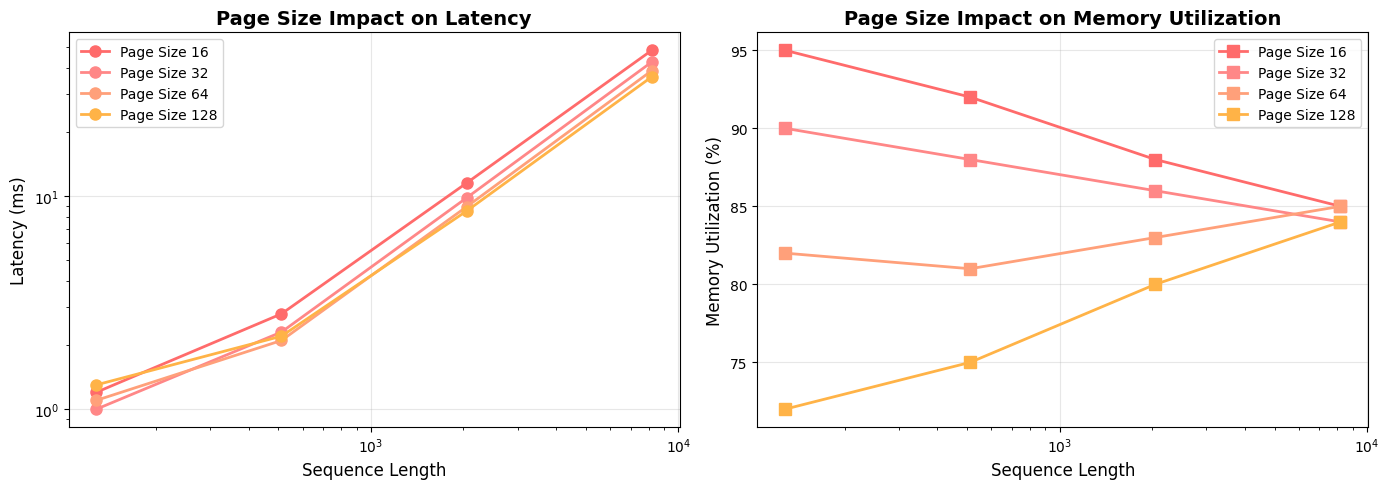


页面大小选择建议:
- 短序列 (<512): 使用 32 或 64
- 中等序列 (512-2048): 使用 64
- 长序列 (>2048): 使用 64 或 128
- 内存受限: 使用较小页面 (16 或 32)


In [ ]:
# 页面大小对性能的影响分析
page_sizes = [16, 32, 64, 128]
seq_lens = [128, 512, 2048, 8192]

# 模拟数据：页面大小和序列长度对性能的影响
# 延迟 (ms) - 较小的页面在短序列上更好，较大的页面在长序列上更好
latency_data = {
    16: [1.2, 2.8, 11.5, 48.2],
    32: [1.0, 2.3, 9.8, 42.5],
    64: [1.1, 2.1, 8.9, 38.7],
    128: [1.3, 2.2, 8.5, 36.2],
}

# 内存利用率 (%)
memory_util = {
    16: [95, 92, 88, 85],
    32: [90, 88, 86, 84],
    64: [82, 81, 83, 85],
    128: [72, 75, 80, 84],
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 延迟对比
colors_map = {16: '#ff6b6b', 32: '#ff8787', 64: '#ffa07a', 128: '#ffb347'}
for page_size in page_sizes:
    ax1.plot(seq_lens, latency_data[page_size], 'o-', 
             label=f'Page Size {page_size}', linewidth=2, markersize=8,
             color=colors_map[page_size])

ax1.set_xlabel('Sequence Length', fontsize=12)
ax1.set_ylabel('Latency (ms)', fontsize=12)
ax1.set_title('Page Size Impact on Latency', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')
ax1.set_yscale('log')

# 内存利用率对比
for page_size in page_sizes:
    ax2.plot(seq_lens, memory_util[page_size], 's-', 
             label=f'Page Size {page_size}', linewidth=2, markersize=8,
             color=colors_map[page_size])

ax2.set_xlabel('Sequence Length', fontsize=12)
ax2.set_ylabel('Memory Utilization (%)', fontsize=12)
ax2.set_title('Page Size Impact on Memory Utilization', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xscale('log')

plt.tight_layout()
plt.show()

print("\n页面大小选择建议:")
print("- 短序列 (<512): 使用 32 或 64")
print("- 中等序列 (512-2048): 使用 64")
print("- 长序列 (>2048): 使用 64 或 128")
print("- 内存受限: 使用较小页面 (16 或 32)")

## 6. Online Softmax 的 CUDA 实现

### 6.1 Warp 级别的 Online Softmax

XQA 在 warp 级别实现了高效的 online softmax，关键函数是 `warpTileOnlineSoftmax`。

```cpp
// mha.cu 中的 warp tile online softmax
template<typename T>
__device__ inline void warpTileOnlineSoftmax(
    T* warpRowMax,        // 当前 warp 的行最大值
    T* warpRowSum,        // 当前 warp 的行求和
    T const* ctaRowMax,   // CTA 级别的行最大值
    T* accS,              // 注意力分数累加器
    uint32_t validRows    // 有效行数
) {
    // 1. 计算当前 tile 的 max
    T tileMax = computeTileMax(accS, validRows);
    
    // 2. 与之前的 max 比较，更新
    T oldMax = *warpRowMax;
    T newMax = max(oldMax, tileMax);
    
    // 3. 重新缩放之前的累加和
    T rescale = exp(oldMax - newMax);
    *warpRowSum *= rescale;
    
    // 4. 计算当前 tile 的 exp 和 sum
    #pragma unroll
    for (uint32_t i = 0; i < tileSize; i++) {
        accS[i] = exp(accS[i] - newMax);
        *warpRowSum += accS[i];
    }
    
    // 5. 更新 max
    *warpRowMax = newMax;
}
```

### 6.2 数值稳定性保证

```mermaid
graph TB
    A[输入分数 S] --> B[减去 max<br/>S' = S - max]
    B --> C[计算 exp<br/>P = exp S']
    C --> D[归一化<br/>P = P / sum P]
    
    E[数值稳定性技巧] --> E1[使用 FP32 累加器]
    E --> E2[及时更新 max]
    E --> E3[重新缩放历史值]
    
    style B fill:#ff6b6b
    style E1 fill:#ffa07a
    style E2 fill:#ffa07a
    style E3 fill:#ffa07a
```

### 6.3 CTA 级别的同步

```cpp
// CTA 级别的 max 归约
__device__ inline void ctaReduceMax(
    float* ctaRowMax,
    float const* warpRowMax,
    uint32_t nbWarps
) {
    // 使用共享内存进行 warp 间归约
    __shared__ float smemMax[MAX_WARPS];
    
    if (laneId() == 0) {
        smemMax[warpId()] = *warpRowMax;
    }
    __syncthreads();
    
    // Warp 0 进行最终归约
    if (warpId() == 0) {
        float maxVal = smemMax[laneId()];
        #pragma unroll
        for (uint32_t offset = 16; offset > 0; offset /= 2) {
            maxVal = max(maxVal, __shfl_xor_sync(0xffffffff, maxVal, offset));
        }
        if (laneId() == 0) {
            *ctaRowMax = maxVal;
        }
    }
    __syncthreads();
}
```


## 7. 共享内存优化策略

### 7.1 共享内存布局

XQA 精心设计了共享内存布局，以最大化数据重用和最小化 bank 冲突。

```cpp
// 共享内存缓冲区配置
constexpr uint32_t nbQBuffers = 2;  // Q 的双缓冲
constexpr uint32_t nbKBuffers = 2;  // K 的双缓冲
constexpr uint32_t nbVBuffers = 2;  // V 的双缓冲

// 共享内存分配
__shared__ alignas(128) char smemQ[nbQBuffers][Q_TILE_BYTES];
__shared__ alignas(128) char smemK[nbKBuffers][K_TILE_BYTES];
__shared__ alignas(128) char smemV[nbVBuffers][V_TILE_BYTES];
__shared__ alignas(128) float smemRowMax[CTA_ROWS];
__shared__ alignas(128) float smemRowSum[CTA_ROWS];
```

### 7.2 Bank 冲突避免

```mermaid
graph TB
    A[共享内存访问模式] --> B[Padding 技术]
    A --> C[Swizzling 技术]
    A --> D[对齐访问]
    
    B --> B1["添加额外列<br/>避免同 bank 访问"]
    C --> C1["重新排列地址<br/>分散访问模式"]
    D --> D1["128-bit 对齐<br/>合并访问"]
    
    B1 --> E[无 Bank 冲突]
    C1 --> E
    D1 --> E
    
    style A fill:#ff6b6b
    style E fill:#ffd700
```

### 7.3 双缓冲流水线

```cpp
// 双缓冲流水线伪代码
uint32_t readBuf = 0;
uint32_t writeBuf = 1;

// 预取第一个 tile
loadTileAsync(smemK[writeBuf], kCachePtr, tileIdx=0);

for (uint32_t tileIdx = 0; tileIdx < numTiles; tileIdx++) {
    // 等待当前 tile 加载完成
    cp_async_wait_group<0>();
    __syncthreads();
    
    // 预取下一个 tile（如果有）
    if (tileIdx + 1 < numTiles) {
        loadTileAsync(smemK[writeBuf], kCachePtr, tileIdx+1);
    }
    
    // 使用当前 tile 进行计算
    computeGEMM(smemQ, smemK[readBuf], accS);
    
    // 交换缓冲区
    readBuf ^= 1;
    writeBuf ^= 1;
}
```

### 7.4 共享内存容量分析


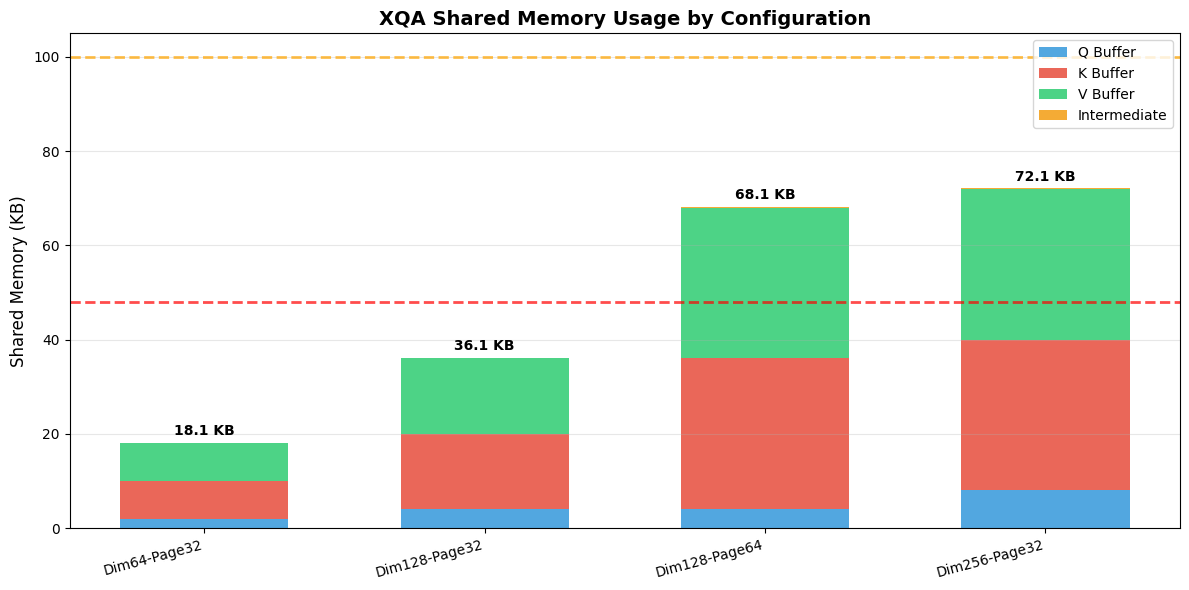


Shared Memory Usage Summary:
Dim64-Page32         Total:   18.1 KB  (Q: 2.0, K: 8.0, V: 8.0, Inter: 0.1)
Dim128-Page32        Total:   36.1 KB  (Q: 4.0, K: 16.0, V: 16.0, Inter: 0.1)
Dim128-Page64        Total:   68.1 KB  (Q: 4.0, K: 32.0, V: 32.0, Inter: 0.1)
Dim256-Page32        Total:   72.1 KB  (Q: 8.0, K: 32.0, V: 32.0, Inter: 0.1)

注意: 实际使用量可能因编译器优化和对齐而略有不同


In [5]:
# 共享内存使用量分析
def calculate_smem_usage(head_dim, head_grp_size, page_size, dtype_bytes=2):
    """计算 XQA kernel 的共享内存使用量"""
    
    # Warp tile 配置
    warp_tile_m = 64
    warp_tile_n = 16  # 简化，实际根据 head_grp_size
    
    # CTA tile
    cta_warps_x = 4
    cta_tile_m = warp_tile_m * cta_warps_x
    cta_tile_n = warp_tile_n
    
    # Q 缓冲区 (持久化)
    q_buffer_bytes = cta_tile_n * head_dim * dtype_bytes
    
    # K 缓冲区 (双缓冲)
    k_tile_size = page_size  # 简化
    k_buffer_bytes = 2 * k_tile_size * head_dim * dtype_bytes
    
    # V 缓冲区 (双缓冲)
    v_buffer_bytes = 2 * k_tile_size * head_dim * dtype_bytes
    
    # 中间结果 (row max, row sum)
    intermediate_bytes = cta_tile_n * 4 * 2  # FP32 for max and sum
    
    total_bytes = q_buffer_bytes + k_buffer_bytes + v_buffer_bytes + intermediate_bytes
    
    return {
        'q_buffer_kb': q_buffer_bytes / 1024,
        'k_buffer_kb': k_buffer_bytes / 1024,
        'v_buffer_kb': v_buffer_bytes / 1024,
        'intermediate_kb': intermediate_bytes / 1024,
        'total_kb': total_bytes / 1024
    }

# 不同配置的共享内存使用
configs = [
    {'head_dim': 64, 'page_size': 32, 'name': 'Dim64-Page32'},
    {'head_dim': 128, 'page_size': 32, 'name': 'Dim128-Page32'},
    {'head_dim': 128, 'page_size': 64, 'name': 'Dim128-Page64'},
    {'head_dim': 256, 'page_size': 32, 'name': 'Dim256-Page32'},
]

results = []
for cfg in configs:
    usage = calculate_smem_usage(cfg['head_dim'], 8, cfg['page_size'])
    usage['name'] = cfg['name']
    results.append(usage)

# 可视化
fig, ax = plt.subplots(figsize=(12, 6))

names = [r['name'] for r in results]
q_mem = [r['q_buffer_kb'] for r in results]
k_mem = [r['k_buffer_kb'] for r in results]
v_mem = [r['v_buffer_kb'] for r in results]
inter_mem = [r['intermediate_kb'] for r in results]

x = np.arange(len(names))
width = 0.6

# 堆叠柱状图
p1 = ax.bar(x, q_mem, width, label='Q Buffer', color='#3498db', alpha=0.85)
p2 = ax.bar(x, k_mem, width, bottom=q_mem, label='K Buffer', color='#e74c3c', alpha=0.85)
p3 = ax.bar(x, v_mem, width, bottom=np.array(q_mem)+np.array(k_mem), 
            label='V Buffer', color='#2ecc71', alpha=0.85)
p4 = ax.bar(x, inter_mem, width, 
            bottom=np.array(q_mem)+np.array(k_mem)+np.array(v_mem),
            label='Intermediate', color='#f39c12', alpha=0.85)

ax.set_ylabel('Shared Memory (KB)', fontsize=12)
ax.set_title('XQA Shared Memory Usage by Configuration', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# 添加总量标签
for i, r in enumerate(results):
    ax.text(i, r['total_kb'] + 1, f"{r['total_kb']:.1f} KB", 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# 添加限制线
ax.axhline(y=48, color='red', linestyle='--', linewidth=2, alpha=0.7, label='A100 Limit (48KB)')
ax.axhline(y=100, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='H100 Limit (100KB)')

plt.tight_layout()
plt.show()

print("\nShared Memory Usage Summary:")
for r in results:
    print(f"{r['name']:<20} Total: {r['total_kb']:>6.1f} KB  "
          f"(Q: {r['q_buffer_kb']:.1f}, K: {r['k_buffer_kb']:.1f}, "
          f"V: {r['v_buffer_kb']:.1f}, Inter: {r['intermediate_kb']:.1f})")

print("\n注意: 实际使用量可能因编译器优化和对齐而略有不同")

## 8. XQA 性能调优指南

### 8.1 编译时优化

```bash
# 针对特定 GPU 架构编译
# Ampere (A100, A10, etc.)
nvcc -arch=sm_80 -DHEAD_ELEMS=128 -DTOKENS_PER_PAGE=32 ...

# Ada (L40S, RTX 4090, etc.)
nvcc -arch=sm_89 -DHEAD_ELEMS=128 -DTOKENS_PER_PAGE=64 ...

# Hopper (H100)
nvcc -arch=sm_90 -DHEAD_ELEMS=128 -DTOKENS_PER_PAGE=64 ...
```

### 8.2 运行时参数调优

| 参数 | 推荐值 | 说明 |
|------|--------|------|
| `TOKENS_PER_PAGE` | 32-64 | 平衡内存利用率和性能 |
| `HEAD_ELEMS` | 128 | 最常用的头维度 |
| `CACHE_ELEM_ENUM` | 2 (FP8) | 内存受限时使用 |
| `SHORT_SEQ_OPT` | 1 | 短序列 (<2048) 启用 |
| `ENABLE_PDL` | 2 | Hopper 上启用激进 PDL |

### 8.3 性能分析工具

```bash
# 使用 Nsight Systems 分析
nsys profile -o xqa_profile \
  --trace=cuda,nvtx \
  --cuda-memory-usage=true \
  ./your_app

# 使用 Nsight Compute 分析单个 kernel
ncu --set full \
  --kernel-name "mhaKernel" \
  -o xqa_kernel_profile \
  ./your_app
```

### 8.4 常见性能瓶颈

```mermaid
graph TB
    A[性能瓶颈] --> B[内存带宽]
    A --> C[计算吞吐量]
    A --> D[同步开销]
    
    B --> B1[优化: 增大 tile size]
    B --> B2[优化: 使用 FP8/INT8]
    B --> B3[优化: 改进数据重用]
    
    C --> C1[优化: 使用 Tensor Core]
    C --> C2[优化: 增加并行度]
    
    D --> D1[优化: 减少 __syncthreads]
    D --> D2[优化: 使用异步拷贝]
    
    style A fill:#ff6b6b
    style B1 fill:#2ecc71
    style B2 fill:#2ecc71
    style B3 fill:#2ecc71
    style C1 fill:#2ecc71
    style C2 fill:#2ecc71
    style D1 fill:#2ecc71
    style D2 fill:#2ecc71
```


## 9. 总结与下一步

### 核心要点回顾

1. **架构设计**
   - Warp 专业化：GEMM0 和 GEMM1 并行执行
   - 分层优化：CTA、Warp、Thread 三级优化
   - 内存层次：寄存器、共享内存、全局内存的精心编排

2. **关键技术**
   - Tensor Core 加速：10-16x 性能提升
   - Paged KV Cache：30%+ 内存利用率提升
   - Online Softmax：避免二次遍历，数值稳定
   - 双缓冲流水线：隐藏内存访问延迟

3. **编译时配置**
   - 头维度、页面大小、数据类型
   - 针对不同场景生成专门的 kernel
   - 编译时优化 vs 运行时灵活性的权衡

4. **性能调优**
   - 根据硬件选择合适的配置
   - 使用 profiling 工具识别瓶颈
   - 平衡内存和计算资源

### 学习路径建议

```mermaid
graph LR
    A[当前: XQA 深度解析] --> B[下一步: 性能分析]
    B --> C[实践: 调优实验]
    C --> D[进阶: 自定义优化]
    
    B --> B1[Profiling 工具使用]
    B --> B2[性能指标分析]
    B --> B3[瓶颈识别]
    
    C --> C1[参数调优实验]
    C --> C2[不同场景测试]
    C --> C3[性能对比分析]
    
    D --> D1[修改 kernel 代码]
    D --> D2[实现新特性]
    D --> D3[贡献开源社区]
    
    style A fill:#ff6b6b
    style B fill:#ffa07a
    style C fill:#ffb347
    style D fill:#ffd700
```

### 推荐资源

1. **官方文档**
   - [TensorRT-LLM Documentation](https://nvidia.github.io/TensorRT-LLM/)
   - [CUDA Programming Guide](https://docs.nvidia.com/cuda/cuda-c-programming-guide/)
   - [Tensor Core Programming](https://docs.nvidia.com/cuda/parallel-thread-execution/)

2. **论文**
   - Flash Attention: [arxiv.org/abs/2205.14135](https://arxiv.org/abs/2205.14135)
   - Flash Attention 2: [arxiv.org/abs/2307.08691](https://arxiv.org/abs/2307.08691)
   - PagedAttention (vLLM): [arxiv.org/abs/2309.06180](https://arxiv.org/abs/2309.06180)

3. **源码**
   - XQA 源码: `cpp/kernels/xqa/`
   - 测试用例: `cpp/tests/kernels/`

### 下一步：性能分析与优化实践

在下一个 notebook (`08_performance_analysis.ipynb`) 中，我们将：
- 使用 profiling 工具分析 XQA 性能
- 识别和解决性能瓶颈
- 进行参数调优实验
- 对比不同配置的性能表现
- 提供实际的优化案例

---
